In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def readucr(filename):
    data = np.loadtxt(filename, delimiter="\t")
    y = data[:, 0]
    x = data[:, 1:]
    return x, y.astype(int)

x_train, y_train = readucr('../datasets/time_series_FordA/FordA_TRAIN.tsv')
x_test, y_test = readucr('../datasets/time_series_FordA/FordA_TEST.tsv')

In [3]:
y_train[y_train == -1] = 0
y_test[y_test == -1] = 0

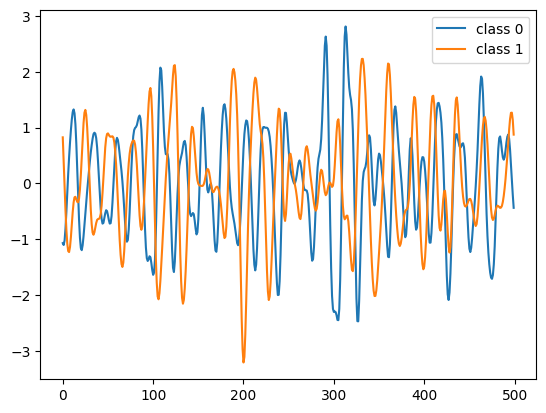

In [4]:
classes = np.unique(np.concatenate((y_train, y_test), axis=0))

plt.figure()
for c in classes:
    c_x_train = x_train[y_train == c]
    plt.plot(c_x_train[4], label="class " + str(c))
plt.legend(loc="best")
plt.show()
plt.close()


In [5]:
x_train.shape

(3601, 500)

In [6]:
# Note that the timeseries data used here are univariate, meaning we only have one channel per timeseries example. 
# We will therefore transform the timeseries into a multivariate one with one channel using a simple reshaping via numpy. 
# This will allow us to construct a model that is easily applicable to multivariate time series.

In [5]:
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
x_train.shape

(3601, 500, 1)

In [6]:
num_classes = len(np.unique(y_train))
num_classes

2

In [7]:
input_shape = (500,1)
input_shape
 

(500, 1)

### Input / Output

* The input of the network is (500, 1), not (500,). This is a choice of the library to accomodate for multiple bands.

* The output is Dense(num_classes, activation="softmax") so node *i* outputs the probability of class *i*
* This is useful to accomodate for multiple classes. Can we try to use a sigmoid instead?

### Inner Layers

* **Conv1D(64, kernel_size=(3)** There are 64 filters 3 each. 

<img src="figures/conv1D.png" width="200"/>

Each filter has (3 * num_bands + 1) paramters (1 is for the bias). Therefore in this case, num_bands = 1, so 4 paramter for each filter. There are 64 filter, 256 parameters in total.
The input of this layer is (500, 1), the output is (500, 64) because padding='same' option. 64 bands for 64 filters.

* **Conv1D(64, kernel_size=(3)** There are 64 filters 3 each. 
Same as before, but 64 * (3 * 64 + 1) = 12.352 parameters.
Note when a filer is applied to a multi-band data, the convolutions of different bands are summed together.
This is why we end up having again a 64 bands output

* **GlobalAveragePooling1D()** computes the average of each feature map across its entire spatial dimensions.
The output is (1,64)

In [8]:
import keras
from keras.layers import Input, Conv1D, GlobalAveragePooling1D, Dense

model = keras.models.Sequential([
Input(shape=input_shape),
Conv1D(filters=64, kernel_size=3, padding="same", activation='relu'),
Conv1D(filters=64, kernel_size=3, padding="same", activation='relu'),
Conv1D(filters=64, kernel_size=3, padding="same", activation='relu'),
GlobalAveragePooling1D(),
Dense(num_classes, activation="softmax")
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 500, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 500, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 500, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,090 (98.01 KB)

 Trainable params: 25,090 (98.01 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
epochs = 500
batch_size = 32

callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=20, min_lr=0.0001
    ),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=50, verbose=1),
]
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 13s 97ms/step - loss: 0.6918 - sparse_categorical_accuracy: 0.5037 - val_loss: 0.6908 - val_sparse_categorical_accuracy: 0.5340 - learning_rate: 0.0010
Epoch 2/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.6834 - sparse_categorical_accuracy: 0.5499 - val_loss: 0.6607 - val_sparse_categorical_accuracy: 0.6671 - learning_rate: 0.0010
Epoch 3/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.6436 - sparse_categorical_accuracy: 0.6122 - val_loss: 0.6067 - val_sparse_categorical_accuracy: 0.4813 - learning_rate: 0.0010
Epoch 4/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.5833 - sparse_categorical_accuracy: 0.6827 - val_loss: 0.5330 - val_sparse_categorical_accuracy: 0.7032 - learning_rate: 0.0010
Epoch 5/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - loss: 0.5162 - sparse_categorical_accuracy: 0.7257 - val_loss: 0.4958 - val_sparse_categorical_accuracy: 0.7337 - learning_rate: 0.0010
Epoch 6/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/

KeyboardInterrupt: 

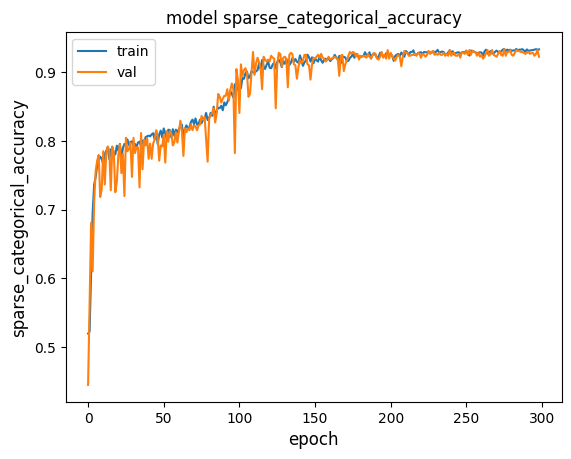

In [12]:
metric = "sparse_categorical_accuracy"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()

In [15]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test accuracy", test_acc)
print("Test loss", test_loss)

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2069 - sparse_categorical_accuracy: 0.9188
Test accuracy 0.9083333611488342
Test loss 0.22096846997737885


In [13]:
prediction = model.predict(x_test)

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [14]:
prediction[:2]

array([[1.0000000e+00, 1.4470743e-10],
       [1.0000000e+00, 2.8926875e-10]], dtype=float32)